# SWOT along-track spectra: synthetic-data reproduction (Du et al. 2026)

This notebook reproduces the paper's core synthetic experiment end to
end, using only generated data (no SWOT files needed):

1. Generate a 2-D Gaussian random field at 250-m posting: a steep
   Matern-kernel ocean signal (asymptoting to a `k^-4` isotropic slope,
   imitating surface-buoyancy-driven balanced motion) plus 2-D spatially
   uncorrelated (white) measurement noise.
2. Compute its **Unsmoothed (250-m) 1-D along-track spectrum** directly.
3. Compute its **2-D spectrum** `S0(kx, ky)`, multiply by the real 2-D
   Hamming-filter transfer function `|H(kx,ky)|^2`, integrate over `ky`,
   and truncate at the 2-km Nyquist wavenumber — this is the
   **no-aliasing prediction** for what the 2-km product spectrum would
   look like if subsampling introduced no aliasing.
4. Actually **apply** the same 17-point 2-D Hamming filter to the
   synthetic field and **subsample** it by a factor of 8 (250 m -> 2 km),
   exactly mimicking real SWOT processing, and compute the 1-D spectrum
   of the result — this is the **ground-truth aliased "Expert" spectrum**.

Because everything here is synthetic, we know the truth: any gap between
curves (3) and (4) is aliasing, full stop, with no data-quality
confounds. This is the same comparison as
`swot_spectra_comparison.ipynb`, but self-contained.

The synthetic swath is one-sided (no nadir gap, no opposite swath), so
this notebook calls `compute_swath_spectra` / `compute_swath_spectra_2d`
directly rather than the both-swaths `compute_pass_spectra*` wrappers.

Only dependency: `swot_alongtrack_spectra.py` and `swot_2d_spectra.py`
in the same directory as this notebook.

## 0. Imports

In [10]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as gamma_fn
from scipy.ndimage import convolve1d

sys.path.insert(0, str(Path.cwd()))

from swot_analysis import compute_pass_spectra,compute_swath_spectra
from swot_analysis.swot_2d_spectra_synthetic import compute_swath_spectra_2d

_trapz = getattr(np, "trapezoid", None) or np.trapz

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(42)

## 1. Synthetic field parameters

All SSHA values in this notebook are generated directly in
**centimeters**, matching the units of the SWOT prelaunch noise
requirement used below, so no unit conversion is needed downstream
(`PSD_UNIT_SCALE = 1.0`).

- Domain: `LX_KM x LY_KM` at `DX_KM` posting (250 m), mirroring one
  SWOT swath (50 km cross-track x 500 km along-track in the paper).
- Ocean signal: isotropic 2-D Matern spectrum, smoothness `NU = 1.5`,
  asymptoting to a `k^-4` along-track/isotropic slope at high
  wavenumber (surface-buoyancy-driven balanced motion, Held et al. 1995).
- Noise: 2-D white noise, level set from significant wave height (SWH)
  following the paper's scaling of the SWOT prelaunch noise requirement
  (Eq. 1). The SWH -> noise-level mapping used here is an illustrative
  monotonic approximation (the paper uses tabulated values from
  Peral et al. 2024, Fig. 30a, which aren't reproduced here) — swap in
  your own scaling if you need the exact numbers.

In [2]:
DX_KM = 0.25                # native (Unsmoothed) posting, km
LX_KM = 500.0                # along-track domain length, km
LY_KM = 50.0                 # cross-track domain length (one swath), km

NU = 1.5                     # Matern smoothness
L_KM = 25.0                  # Matern length scale, km
SIGMA2_CM2 = 400.0           # ocean-signal variance, cm^2 (20 cm rms)

SWH_M = 4.0                  # significant wave height used to set the noise level

DX_EXPERT_KM = 2.0           # Expert product posting
SUBSAMPLE_FACTOR = int(round(DX_EXPERT_KM / DX_KM))   # 8
K_NY_2KM = 1.0 / (2.0 * DX_EXPERT_KM)                   # 0.25 cpkm

PSD_UNIT_SCALE = 1.0         # field already in cm -> PSD already in cm^2/cpkm

Nx = int(round(LX_KM / DX_KM))
Ny = int(round(LY_KM / DX_KM))
print(f"Grid: {Nx} x {Ny} at {DX_KM} km posting "
      f"({LX_KM} km along-track x {LY_KM} km cross-track)")

Grid: 2000 x 200 at 0.25 km posting (500.0 km along-track x 50.0 km cross-track)


In [3]:
def swot_white_noise_level_cm2_per_cpkm(swh_m):
    """Illustrative SWH -> white-noise-level scaling, anchored to the
    paper's Eq. (1) for SWH = 2 m (SWOT prelaunch noise requirement
    scaled to 250-m posting, corrected by the 2.3x preliminary factor),
    with a simple power-law dependence on SWH above that. Replace the
    `scale` relationship with tabulated values (e.g. from Peral et al.
    2024, Fig. 30a) for a quantitatively faithful reproduction."""
    N0_2m = 2.0 * (15.0 / 0.5) * (1.0 / 2.3) ** 2   # cm^2 cpkm^-1, SWH = 2 m
    scale = (swh_m / 2.0) ** 1.5
    return N0_2m * scale


N0 = swot_white_noise_level_cm2_per_cpkm(SWH_M)
print(f"White-noise level for SWH={SWH_M} m: {N0:.3f} cm^2 cpkm^-1")

White-noise level for SWH=4.0 m: 32.080 cm^2 cpkm^-1


## 2. Target 2-D power spectrum and Gaussian random field synthesis

The 2-D isotropic Matern PSD (Stein 1999, p. 49) plus a flat white-noise
floor:

$$S_0(k_x,k_y) = \sigma^2\,\frac{4\pi\nu}{L^2}\,\frac{\Gamma(\nu+1)}{\Gamma(\nu)}\left(\frac{2\nu}{L^2}+4\pi^2(k_x^2+k_y^2)\right)^{-(\nu+1)} + N_0$$

The field is synthesized by the standard spectral method: FFT a unit-
variance real white-noise field (its expected PSD is exactly flat, level
`dx*dy`), rescale each Fourier coefficient by `sqrt(S0(k)/(dx*dy))`, and
inverse-FFT. Because `S0(k)` is even and the FFT of real white noise is
already Hermitian-symmetric, the result is (numerically) real without
needing to discard an imaginary part.

In [4]:
def matern_psd_2d(kx, ky, sigma2, L, nu):
    """2-D (d=2) isotropic Matern spectral density (Stein 1999, p. 49),
    normalized so its integral over the full (unbounded) kx,ky plane
    equals sigma2 -- i.e. sigma2 is the true field variance contributed
    by this component."""
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    K2 = KX ** 2 + KY ** 2
    kappa2 = 2.0 * nu / L ** 2
    C = 4.0 * np.pi * gamma_fn(nu + 1) * (2.0 * nu) ** nu / (gamma_fn(nu) * L ** (2.0 * nu))
    return sigma2 * C * (kappa2 + 4.0 * np.pi ** 2 * K2) ** (-(nu + 1))


def synthesize_gaussian_field(Nx, Ny, dx_km, dy_km, sigma2, L, nu, N0, rng):
    kx = np.fft.fftfreq(Nx, d=dx_km)
    ky = np.fft.fftfreq(Ny, d=dy_km)
    S0 = matern_psd_2d(kx, ky, sigma2, L, nu) + N0

    white = rng.standard_normal((Nx, Ny))
    W = np.fft.fft2(white)
    A = W * np.sqrt(S0 / (dx_km * dy_km))
    field = np.fft.ifft2(A).real
    return field, kx, ky, S0


field_us, kx_gen, ky_gen, S0_true = synthesize_gaussian_field(
    Nx, Ny, DX_KM, DX_KM, SIGMA2_CM2, L_KM, NU, N0, rng
)
print(f"Synthetic field: shape={field_us.shape}, "
      f"std={field_us.std():.3f} cm, mean={field_us.mean():.4f} cm")

Synthetic field: shape=(2000, 200), std=32.567 cm, mean=0.1461 cm


## 3. Package the field as a synthetic "Unsmoothed" granule

Builds the `(ssha, latitude, longitude, cross_track_distance)` arrays
in the same layout `compute_swath_spectra` / `compute_swath_spectra_2d`
expect: rows = along-track, columns = cross-track. Latitude/longitude
are a simple equirectangular placeholder (only used to build the
along-track distance axis internally, so any consistent geometry
works). Cross-track distance is all positive (0 to `LY_KM` km): a
single one-sided swath, since there's no real nadir gap or opposite
swath in this idealized setup.

In [5]:
LAT0, LON0 = 30.0, -130.0
KM_PER_DEG_LAT = 111.0

along_idx = np.arange(Nx)
cross_idx = np.arange(Ny)

lat_us = LAT0 + (along_idx * DX_KM / KM_PER_DEG_LAT)[:, None] * np.ones((1, Ny))
lon_us = LON0 + np.zeros((Nx, Ny))

xt_us_1d = (cross_idx + 0.5) * DX_KM   # 0.125 ... LY_KM, all positive
xtrack_us = np.tile(xt_us_1d, (Nx, 1))

ssha_us = field_us

swath_mask_us = np.ones(Ny, dtype=bool)   # every column belongs to this synthetic swath
print(f"Swath: {swath_mask_us.sum()} of {Ny} columns")

Swath: 200 of 200 columns


## 4. Actually apply the SWOT 2-D Hamming filter and subsample

This is the ground-truth analog of real SWOT on-ground processing:
convolve with the same 17-point separable 2-D Hamming kernel used in
the earlier notebook, then take every 8th sample in both directions
(250 m x 8 = 2 km) to build the synthetic "Expert" product. `mode
="reflect"` avoids artificial zero-padding at the domain edges; discard
a small buffer at each edge afterward so boundary handling doesn't
contaminate the spectra.

In [6]:
def hamming_1d_taps(n=17):
    m = np.arange(n) - (n - 1) / 2
    w = 0.54 - 0.46 * np.cos(2 * np.pi * (m + (n - 1) / 2) / (n - 1))
    return m, w / w.sum()


def hamming_transfer_1d(k, dx_km, n=17):
    m, w = hamming_1d_taps(n)
    k = np.asarray(k, dtype=float)
    phase = 2 * np.pi * np.multiply.outer(k, m * dx_km)
    return (w * np.cos(phase)).sum(axis=-1)


def hamming_transfer_2d(kx, ky, dx_km, dy_km, n=17):
    Wx = hamming_transfer_1d(kx, dx_km, n=n)
    Wy = hamming_transfer_1d(ky, dy_km, n=n)
    return np.outer(Wx ** 2, Wy ** 2)


_, taps = hamming_1d_taps(17)
field_filt = convolve1d(field_us, taps, axis=0, mode="reflect")
field_filt = convolve1d(field_filt, taps, axis=1, mode="reflect")

EDGE_BUFFER_PIX = 17   # drop ~ one kernel half-width of edge-affected rows/cols
field_filt = field_filt[EDGE_BUFFER_PIX:-EDGE_BUFFER_PIX, EDGE_BUFFER_PIX:-EDGE_BUFFER_PIX]
lat_filt = lat_us[EDGE_BUFFER_PIX:-EDGE_BUFFER_PIX, EDGE_BUFFER_PIX:-EDGE_BUFFER_PIX]
lon_filt = lon_us[EDGE_BUFFER_PIX:-EDGE_BUFFER_PIX, EDGE_BUFFER_PIX:-EDGE_BUFFER_PIX]
xtrack_filt = xtrack_us[EDGE_BUFFER_PIX:-EDGE_BUFFER_PIX, EDGE_BUFFER_PIX:-EDGE_BUFFER_PIX]

ssha_ex = field_filt[::SUBSAMPLE_FACTOR, ::SUBSAMPLE_FACTOR]
lat_ex = lat_filt[::SUBSAMPLE_FACTOR, ::SUBSAMPLE_FACTOR]
lon_ex = lon_filt[::SUBSAMPLE_FACTOR, ::SUBSAMPLE_FACTOR]
xtrack_ex = xtrack_filt[::SUBSAMPLE_FACTOR, ::SUBSAMPLE_FACTOR]

swath_mask_ex = np.ones(xtrack_ex.shape[1], dtype=bool)

print(f"Synthetic Expert (2-km) product: shape={ssha_ex.shape}")

Synthetic Expert (2-km) product: shape=(246, 21)


## 5. Analysis parameters

In [7]:
SEGMENT_LENGTH_KM = 50.0
OVERLAP = 0.5
SWATH_NAME = "synthetic"

## 6. Unsmoothed 1-D along-track spectrum (direct)

In [11]:
result_us_1d = compute_swath_spectra(
    ssha=ssha_us, latitude=lat_us, longitude=lon_us,
    swath_mask=swath_mask_us, swath_name=SWATH_NAME,
    segment_length_km=SEGMENT_LENGTH_KM, overlap=OVERLAP,
)
kx_us_1d = result_us_1d.wavenumber
psd_us_1d = result_us_1d.mean_psd * PSD_UNIT_SCALE
print(f"Unsmoothed 1-D: {result_us_1d.n_segments_used}/{result_us_1d.n_segments_total} segments used")

Unsmoothed 1-D: 14/20 segments used


## 7. Unsmoothed 2-D spectrum S0(kx, ky)

In [12]:
result_us_2d = compute_swath_spectra_2d(
    ssha=ssha_us, latitude=lat_us, longitude=lon_us,
    cross_track_distance=xtrack_us,
    swath_mask=swath_mask_us, swath_name=SWATH_NAME,
    segment_length_km=SEGMENT_LENGTH_KM, overlap=OVERLAP,
)
kx_2d = result_us_2d.wavenumber_x
ky_2d = result_us_2d.wavenumber_y
S0_est = result_us_2d.mean_psd_2d
print(f"Unsmoothed 2-D: {result_us_2d.n_segments_used}/{result_us_2d.n_segments_total} segments used")

Unsmoothed 2-D: 14/20 segments used


## 8. Hamming transfer function, filtering, and the no-aliasing prediction

$$S_{\rm filt}(k_x,k_y) = |H(k_x,k_y)|^2\,S_0(k_x,k_y)$$

$$S_{1D}^{\,2km,\ \rm no\text{-}alias}(k_x) = \int_{-k_{Ny}^{250}}^{k_{Ny}^{250}} S_{\rm filt}(k_x,k_y)\,dk_y,\qquad |k_x|\le k_{Ny}^{2km}$$

In [13]:
dkx = np.diff(kx_2d).mean()
dky = np.diff(ky_2d).mean()
dx_native_km = 1.0 / (len(kx_2d) * dkx)
dy_native_km = 1.0 / (len(ky_2d) * dky)

H2 = hamming_transfer_2d(kx_2d, ky_2d, dx_native_km, dy_native_km)

kx_pos = kx_2d[kx_2d > 0]
Wx_pos = hamming_transfer_1d(kx_pos, dx_native_km) ** 2
k_half = kx_pos[np.argmin(np.abs(Wx_pos - 0.5))]
print(f"Along-track half-power wavenumber: {k_half:.4f} cpkm "
      f"(wavelength {1/k_half:.2f} km; expected ~6.28 km)")

S_filt = H2 * S0_est
S1D_filt_two_sided = _trapz(S_filt, x=ky_2d, axis=1)


def to_one_sided(k, S):
    k = np.asarray(k)
    pos, zero = k > 0, k == 0
    k_os = np.concatenate([k[zero], k[pos]])
    S_os = np.concatenate([S[zero], 2.0 * S[pos]])
    order = np.argsort(k_os)
    return k_os[order], S_os[order]


kx_filt_os, S1D_filt_os = to_one_sided(kx_2d, S1D_filt_two_sided)
in_2km_band = np.abs(kx_filt_os) <= K_NY_2KM
kx_noalias = kx_filt_os[in_2km_band]
psd_noalias = S1D_filt_os[in_2km_band] * PSD_UNIT_SCALE

Along-track half-power wavenumber: 0.1597 cpkm (wavelength 6.26 km; expected ~6.28 km)


## 9. Ground-truth aliased "Expert" spectrum (observed)

Computed directly from the field that was actually Hamming-filtered and
subsampled in Section 4 — this is what real SWOT processing does, and
is *not* an estimate.

In [14]:
result_ex_1d = compute_swath_spectra(
    ssha=ssha_ex, latitude=lat_ex, longitude=lon_ex,
    swath_mask=swath_mask_ex, swath_name=SWATH_NAME,
    segment_length_km=SEGMENT_LENGTH_KM,
    along_track_spacing_km=DX_EXPERT_KM,
    overlap=OVERLAP,
)
kx_ex_1d = result_ex_1d.wavenumber
psd_ex_1d = result_ex_1d.mean_psd * PSD_UNIT_SCALE
print(f"Expert (aliased, ground truth) 1-D: "
      f"{result_ex_1d.n_segments_used}/{result_ex_1d.n_segments_total} segments used")

Expert (aliased, ground truth) 1-D: 19/19 segments used


## 10. Comparison plot (reproduces Fig. 1 of Du et al. 2026)

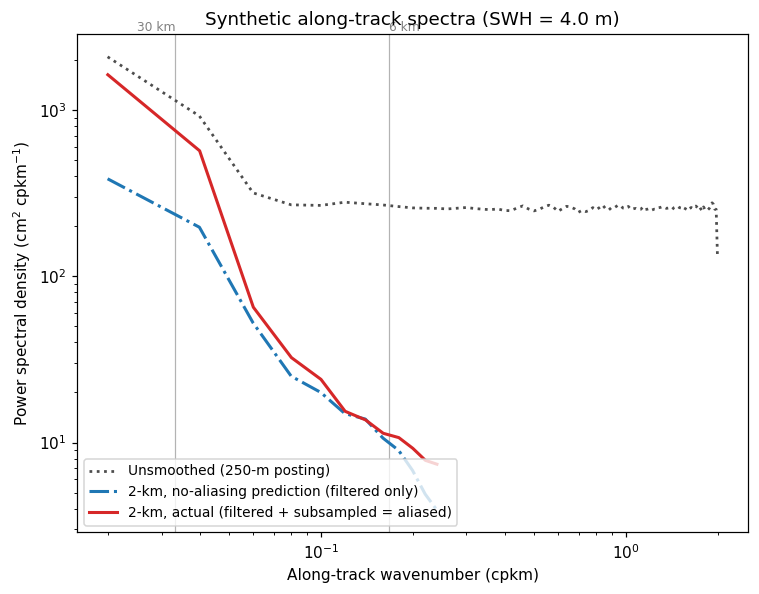

In [15]:
fig, ax = plt.subplots(figsize=(7, 5.5))

mask_us = kx_us_1d > 0
ax.loglog(kx_us_1d[mask_us], psd_us_1d[mask_us],
          ls=":", color="0.3", lw=1.8, label="Unsmoothed (250-m posting)")

ax.loglog(kx_noalias[kx_noalias > 0], psd_noalias[kx_noalias > 0],
          ls="-.", color="tab:blue", lw=2.0,
          label="2-km, no-aliasing prediction (filtered only)")

mask_ex = kx_ex_1d > 0
ax.loglog(kx_ex_1d[mask_ex], psd_ex_1d[mask_ex],
          ls="-", color="tab:red", lw=2.0,
          label="2-km, actual (filtered + subsampled = aliased)")

ax.axvline(1 / 30.0, color="0.7", lw=0.8, zorder=0)
ax.axvline(1 / 6.0, color="0.7", lw=0.8, zorder=0)
ymax = ax.get_ylim()[1]
ax.text(1 / 30.0, ymax, "30 km", ha="right", va="bottom", fontsize=8, color="0.5")
ax.text(1 / 6.0, ymax, "6 km", ha="left", va="bottom", fontsize=8, color="0.5")

ax.set_xlabel("Along-track wavenumber (cpkm)")
ax.set_ylabel("Power spectral density (cm$^2$ cpkm$^{-1}$)")
ax.set_title(f"Synthetic along-track spectra (SWH = {SWH_M} m)")
ax.legend(loc="lower left", fontsize=9)
fig.tight_layout()
fig.savefig("synthetic_spectra_comparison.png", dpi=150)

## 11. (Bonus) Multiple noise levels, Fig.-1 style

Repeats Sections 2, 4, 6-9 for several SWH values, overlaying all three
curves per level with a shared colormap — the direct synthetic analog
of Fig. 1's multi-color panel. Kept self-contained in one cell for
convenience; re-run Sections 1-9 individually above if you want to
inspect any single level in more detail.

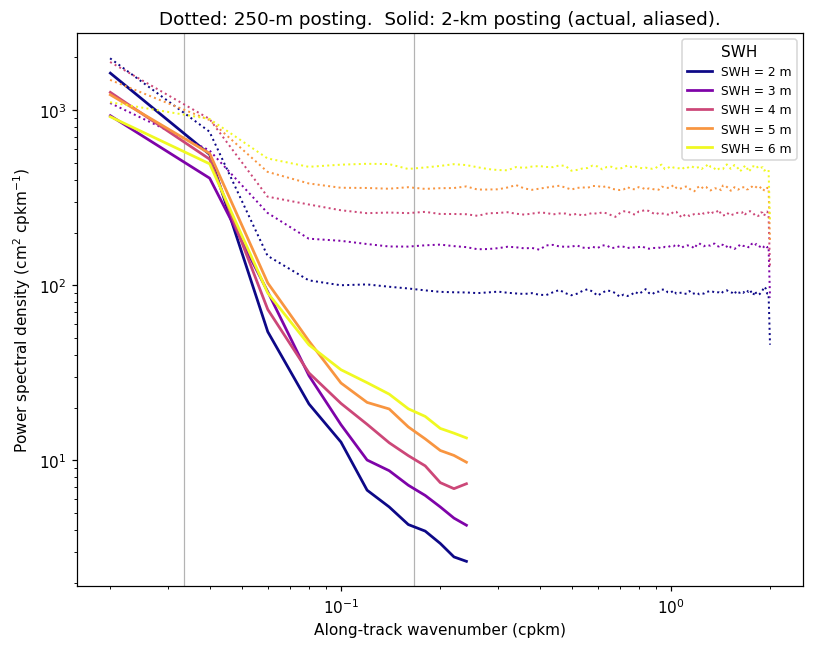

In [16]:
SWH_LEVELS = [2.0, 3.0, 4.0, 5.0, 6.0]
cmap = plt.get_cmap("plasma")
colors = {swh: cmap(i / (len(SWH_LEVELS) - 1)) for i, swh in enumerate(SWH_LEVELS)}

fig, ax = plt.subplots(figsize=(7.5, 6))

for swh in SWH_LEVELS:
    N0_i = swot_white_noise_level_cm2_per_cpkm(swh)
    field_i, _, _, _ = synthesize_gaussian_field(
        Nx, Ny, DX_KM, DX_KM, SIGMA2_CM2, L_KM, NU, N0_i, rng
    )

    filt_i = convolve1d(field_i, taps, axis=0, mode="reflect")
    filt_i = convolve1d(filt_i, taps, axis=1, mode="reflect")
    filt_i = filt_i[EDGE_BUFFER_PIX:-EDGE_BUFFER_PIX, EDGE_BUFFER_PIX:-EDGE_BUFFER_PIX]
    lat_fi = lat_us[EDGE_BUFFER_PIX:-EDGE_BUFFER_PIX, EDGE_BUFFER_PIX:-EDGE_BUFFER_PIX]
    lon_fi = lon_us[EDGE_BUFFER_PIX:-EDGE_BUFFER_PIX, EDGE_BUFFER_PIX:-EDGE_BUFFER_PIX]
    xt_fi = xtrack_us[EDGE_BUFFER_PIX:-EDGE_BUFFER_PIX, EDGE_BUFFER_PIX:-EDGE_BUFFER_PIX]

    ssha_ex_i = filt_i[::SUBSAMPLE_FACTOR, ::SUBSAMPLE_FACTOR]
    lat_ex_i = lat_fi[::SUBSAMPLE_FACTOR, ::SUBSAMPLE_FACTOR]
    lon_ex_i = lon_fi[::SUBSAMPLE_FACTOR, ::SUBSAMPLE_FACTOR]
    xt_ex_i = xt_fi[::SUBSAMPLE_FACTOR, ::SUBSAMPLE_FACTOR]
    swath_mask_ex_i = np.ones(xt_ex_i.shape[1], dtype=bool)

    res_us_i = compute_swath_spectra(
        ssha=field_i, latitude=lat_us, longitude=lon_us,
        swath_mask=swath_mask_us, swath_name=SWATH_NAME,
        segment_length_km=SEGMENT_LENGTH_KM, overlap=OVERLAP,
    )
    res_ex_i = compute_swath_spectra(
        ssha=ssha_ex_i, latitude=lat_ex_i, longitude=lon_ex_i,
        swath_mask=swath_mask_ex_i, swath_name=SWATH_NAME,
        segment_length_km=SEGMENT_LENGTH_KM,
        along_track_spacing_km=DX_EXPERT_KM, overlap=OVERLAP,
    )

    c = colors[swh]
    m_us = res_us_i.wavenumber > 0
    m_ex = res_ex_i.wavenumber > 0
    ax.loglog(res_us_i.wavenumber[m_us], res_us_i.mean_psd[m_us], ls=":", color=c, lw=1.3)
    ax.loglog(res_ex_i.wavenumber[m_ex], res_ex_i.mean_psd[m_ex], ls="-", color=c, lw=1.8,
              label=f"SWH = {swh:g} m")

ax.axvline(1 / 30.0, color="0.7", lw=0.8, zorder=0)
ax.axvline(1 / 6.0, color="0.7", lw=0.8, zorder=0)
ax.set_xlabel("Along-track wavenumber (cpkm)")
ax.set_ylabel("Power spectral density (cm$^2$ cpkm$^{-1}$)")
ax.set_title("Dotted: 250-m posting.  Solid: 2-km posting (actual, aliased).")
ax.legend(fontsize=8, title="SWH")
fig.tight_layout()